In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/mnt/DataVol/Beratungen/Yurttas/survival/src')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

df = pd.read_csv(f"{DATA_PATH}/all_data.csv", sep="\t")
df.columns

Index(['Bday', 'OPDate', 'Sex', 'Zn HIPEC', 'Age', 'Tumor', 'Histo', 'T', 'N',
       'M', 'V', 'L', 'R', 'G', 'syn_met', 'Other M1', 'PreOP CTx',
       'PostOP CTx', 'Thermoablation', 'HIPEC Med', 'HIPEC Zeit', 'NaThio',
       'OP-Zeit', 'Kompli', 'Art Kompli', 'Re-OP durch Kompli',
       'Tod als Kompli', 'In-Hosp Mortalität', 'Tod 30d', 'Tod 90d',
       'Rechtskolon', 'Transkolon', 'Linkskolon', 'sPCI', 'pPCI', 'PCI Diff',
       'Präparate gesamt', 'Präparate positiv', 'Mutation', 'CC', 'Tod Datum',
       'OS', 'Rezidiv', 'Lok Rezidiv', 'Datum Rezidiv', 'Zeit bis Rezidiv',
       'SF Grund'],
      dtype='object')

In [4]:
cols_to_use = ["Sex", "Age", "Tumor", "CC", "PreOP CTx", "Thermoablation", "sPCI", "pPCI"]
df = df[cols_to_use].copy()

In [5]:
df.head()

,Sex,Age,Tumor,CC,PreOP CTx,Thermoablation,sPCI,pPCI
0,2,17,1,1,1,1,26,22
1,1,21,1,0,5,1,5,3
2,1,23,2,0,0,1,10,1
3,2,23,4,1,1,0,15,6
4,2,23,18,0,0,1,11,4


## Variable overview

**Binary predictors**
- `Sex` (0/1, recoded from original 1/2)
- `CC` (0/1; only CC0 and CC1 retained)
- `Thermoablation` (0/1)
- `PreOP_CTx` (0/1; binarised: ≥1 → 1)

**Continuous predictor**
- `Age`

**Nominal predictor — one-hot encoded**
- `Tumor` (types 2–7; reference category = type_1, n=122, most frequent; type_8 excluded)
  - `Tumor_type_2`, `Tumor_type_3`, `Tumor_type_4`, `Tumor_type_5`, `Tumor_type_6`, `Tumor_type_7`

**Outcome variables**
- `raw_diff` = sPCI − pPCI  (signed difference)
- `abs_diff` = |raw_diff|   (absolute difference)


In [6]:
# data wrangling
df['Sex'] = df['Sex']-1
df['PreOP CTx'] = df['PreOP CTx'].apply(lambda x: 1 if x >= 1 else x)

keep_tumor = [1, 5, 4, 6, 7, 3, 2]  # remove 8 if you decide to drop it

# Filter rows
df = df[df["Tumor"].isin(keep_tumor)].copy()
df['Tumor'] = df['Tumor'].apply(lambda x: f"type_{x}")

df = df[(df['CC']==0) | (df['CC']==1)].reset_index(drop=True)  # keep only CC0 and CC1


In [7]:
df.shape

(409, 8)

In [8]:
# --- 1. Rename columns ---
df = df.rename(columns={
    "PreOP CTx" : "PreOP_CTx",
})

In [9]:
# --- 5. One-hot encode Tumor (most frequent as reference) ---
# Tumor "1" (n=122) is the natural reference category
df = pd.get_dummies(df, columns=["Tumor"], drop_first=False, dtype=int)
df = df.drop(columns=["Tumor_type_1"], inplace=False)  # explicitly set Tumor_1 as reference

# --- 6. Create outcome variables ---
df["raw_diff"] = df["sPCI"] - df["pPCI"]
df["abs_diff"] = np.abs(df["raw_diff"])


In [10]:
feature_cols = [
    'Sex', 'Age', 'CC', 'PreOP_CTx', 'Thermoablation', 'Tumor_type_2', 'Tumor_type_3', 'Tumor_type_4', 'Tumor_type_5',
       'Tumor_type_6', 'Tumor_type_7'
]

X     = df[feature_cols]
y_raw = df["raw_diff"]
y_abs = df["abs_diff"]

print(f"Final feature matrix: {X.shape}")

Final feature matrix: (409, 11)


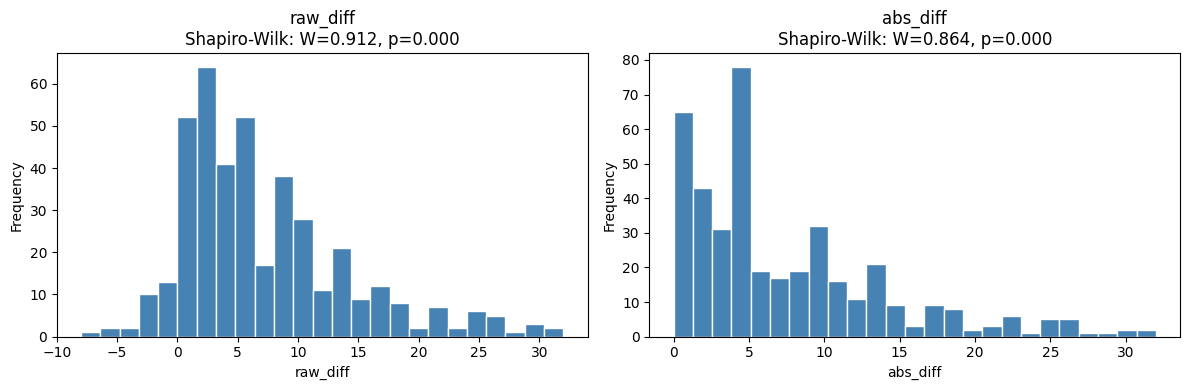

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, outcome, label in zip(axes, [y_raw, y_abs], ["raw_diff", "abs_diff"]):
    ax.hist(outcome, bins=25, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    stat, p = stats.shapiro(outcome)
    ax.set_title(f"{label}\nShapiro-Wilk: W={stat:.3f}, p={p:.3f}")

plt.tight_layout()
plt.show()

In [12]:
import statsmodels.api as sm

X = sm.add_constant(X)  # if not already included
model = sm.OLS(y_raw, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               raw_diff   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     21.48
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.02e-34
Time:                        14:16:18   Log-Likelihood:                -1280.7
No. Observations:                 409   AIC:                             2585.
Df Residuals:                     397   BIC:                             2634.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              6.2250      1.689      3.

In [13]:
fitted = model.fittedvalues
residuals = model.resid

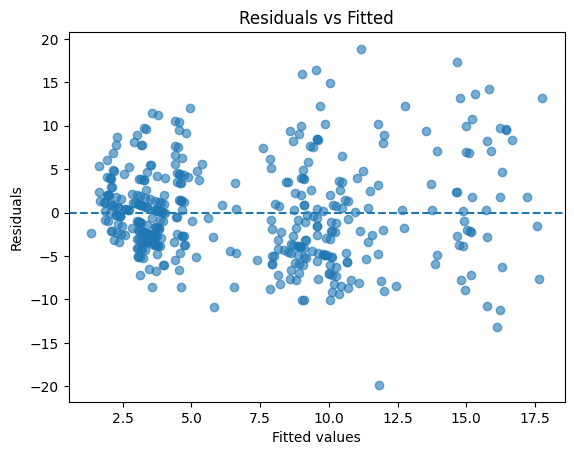

In [14]:
import matplotlib.pyplot as plt

plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

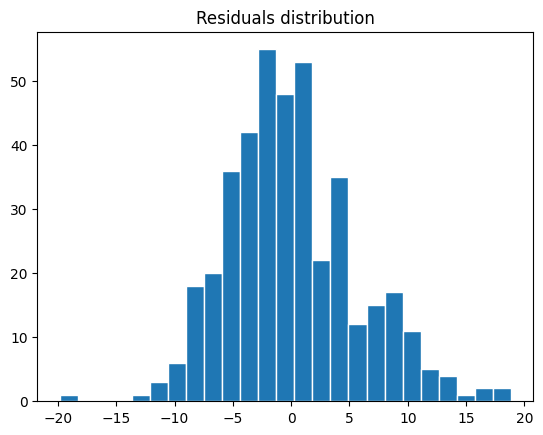

In [15]:
plt.hist(residuals, bins=25, edgecolor="white")
plt.title("Residuals distribution")
plt.show()

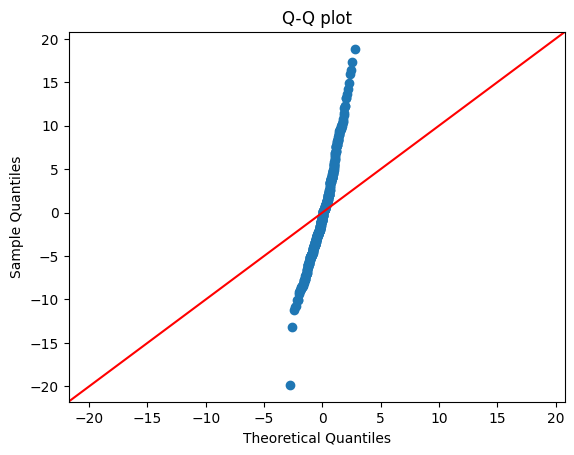

In [16]:
import statsmodels.api as sm

sm.qqplot(residuals, line='45')
plt.title("Q-Q plot")
plt.show()

In [17]:
from scipy import stats
stat, p = stats.shapiro(residuals)
print(f"W={stat:.3f}, p={p:.3f}")

W=0.980, p=0.000


In [18]:
from statsmodels.stats.diagnostic import het_breuschpagan

lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(residuals, X)

print(f"LM p-value: {lm_pvalue:.4f}")

LM p-value: 0.0000


## Conclusions

### Study sample

**N = 409** patients after excluding tumour type 8 and CC > 1. Tumour type 1 (n = 122) is the reference category. Outcome: **raw\_diff = sPCI − pPCI** (signed discordance).

### OLS model

**R² = 0.373, Adjusted R² = 0.356.** Overall F(11, 397) = 21.48, p = 3.0 × 10⁻³⁴.

| Predictor | Coef | 95 % CI | p |
|---|---|---|---|
| **CC (incomplete)** | **+6.02** | **[+4.81, +7.22]** | **< 0.001** |
| **Tumour type 5** | **+6.79** | **[+5.17, +8.41]** | **< 0.001** |
| **Tumour type 7** | **+4.45** | **[+2.03, +6.87]** | **< 0.001** |
| **Thermoablation** | **−1.39** | **[−2.76, −0.02]** | **0.047** |
| Sex (male) | −1.15 | [−2.40, +0.11] | 0.074 |
| Tumour type 4 | +1.64 | [−0.17, +3.45] | 0.076 |
| Age | −0.01 | [−0.06, +0.03] | 0.568 |
| PreOP CTx | −0.85 | [−2.32, +0.63] | 0.260 |
| Tumour types 2, 3, 6 | — | — | NS |

### Significant predictors

1. **CC (incomplete cytoreduction)** (+6.0 pts, p < 0.001) — the strongest predictor; patients with incomplete resection show substantially greater intraoperative vs. pathological discordance.
2. **Tumour type 5** (+6.8 pts vs. type 1, p < 0.001) — largest tumour-type effect.
3. **Tumour type 7** (+4.5 pts vs. type 1, p < 0.001).
4. **Thermoablation** (−1.4 pts, p = 0.047) — borderline; likely reflects patient selection rather than a causal effect.

### Residual diagnostics

| Test | Result | Interpretation |
|---|---|---|
| Shapiro-Wilk | W = 0.980, p < 0.001 | Residuals non-normal |
| Jarque-Bera | JB = 20.16, p < 0.001 | Confirms non-normality |
| Breusch-Pagan | LM p < 0.001 | Heteroscedasticity present |
| Durbin-Watson | 1.980 | No autocorrelation |
| Skewness / Kurtosis | 0.48 / 3.52 | Mild right skew, slightly leptokurtic |

Both normality and homoscedasticity are violated. OLS standard errors are unreliable; p-values may be anti-conservative.

### Next step

Re-estimate with **Huber M-estimator (RLM)** and bootstrap CIs — see . The robust model yields consistent conclusions for all four significant predictors with attenuated effect sizes (CC: +5.5, tumour type 5: +5.9, tumour type 7: +4.2, thermoablation: −1.6).
